In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Answer the following questions using Pandas and Matplotlib:
- What are the total sales quantities for each drug category (ATC code)?
- Which individual drug brands have the highest total sales?
- Which three drugs have the highest sales in January 2015, July 2016, September 2017.
- Which drug has sold the most often in 2017?
- Which drug category has the highest average daily sales?
- Are respiratory drugs (R03) sold more during specific months?

In [2]:
sales = pd.read_csv("saleshourly.csv")

In [3]:
sales.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  str    
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02BA         50532 non-null  float64
 4   N02BE         50532 non-null  float64
 5   N05B          50532 non-null  float64
 6   N05C          50532 non-null  float64
 7   R03           50532 non-null  float64
 8   R06           50532 non-null  float64
 9   Year          50532 non-null  int64  
 10  Month         50532 non-null  int64  
 11  Hour          50532 non-null  int64  
 12  Weekday Name  50532 non-null  str    
dtypes: float64(8), int64(3), str(2)
memory usage: 6.1 MB


In [5]:
sales.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [6]:
sales.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

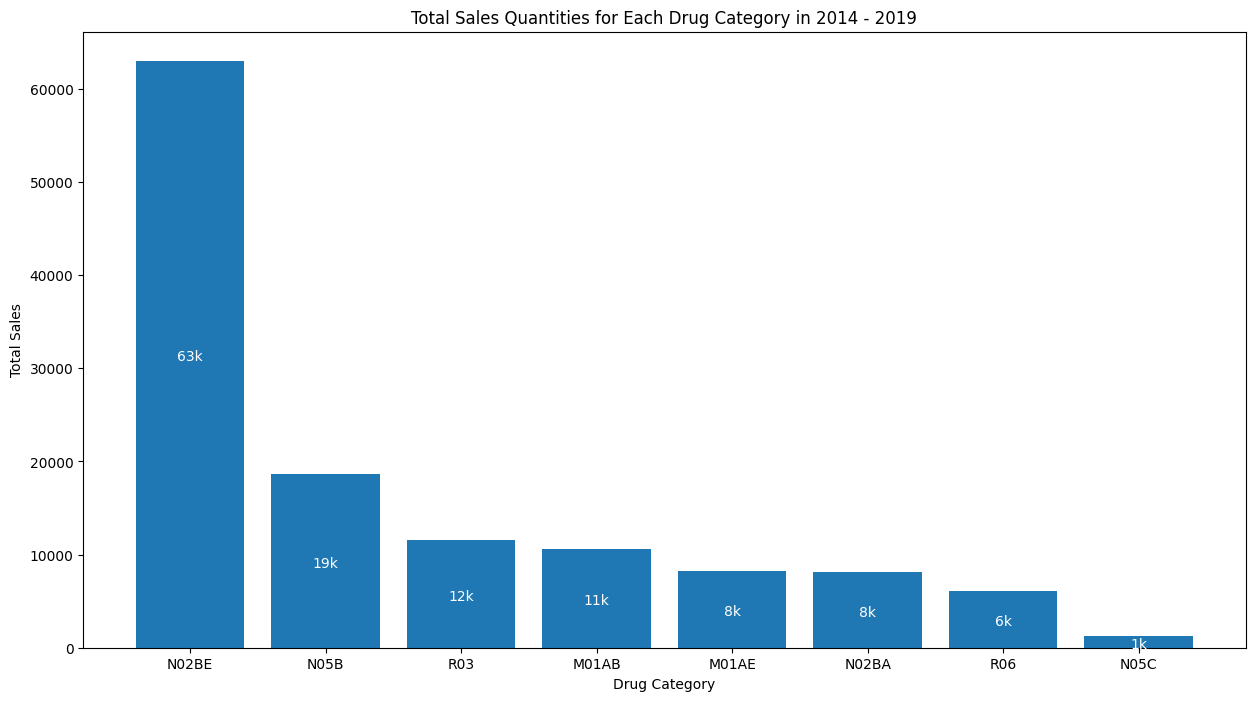

In [7]:
# Answering Question 1 + 2: 
# What are the total sales quantities for each drug category (ATC code)?
# Which individual drug brands have the highest total sales? 

q1 = sales[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03','R06']].sum(
     axis=0).sort_values(ascending=False).reset_index(name='total_sales').rename(columns={"index": "drug_category"})

plt.figure(figsize = (15,8))
plt.bar(q1['drug_category'], q1['total_sales'])
plt.title("Total Sales Quantities for Each Drug Category in 2014 - 2019")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")
for i, ts in enumerate(q1["total_sales"]):
    plt.text(
        x=i,                      
        y=ts / 2 - 250,                 
        s=f"{ts / 1000:.0f}k",       
        ha="center",
        va="center",
        color="white",
        fontsize=10,
    )
plt.show()

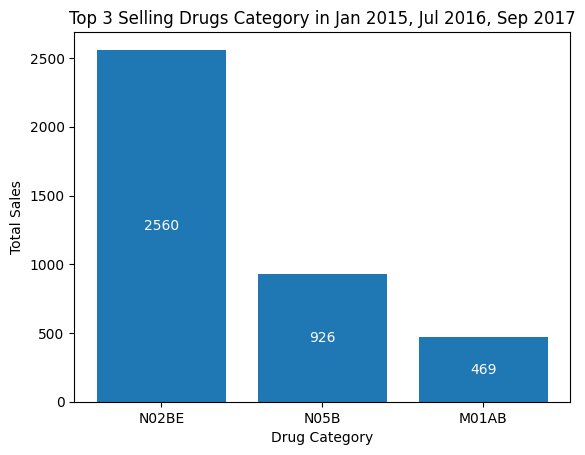

In [8]:
# Answering Question 3: 
# Which three drugs have the highest sales in January 2015, July 2016, September 2017.

q3 = sales.loc[((sales['Year'] == 2015) & (sales['Month'] == 1)) | 
               ((sales['Year'] == 2016) & (sales['Month'] == 7)) |
               ((sales['Year'] == 2017) & (sales['Month'] == 9))]

q3 = q3[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03','R06']].sum(
     axis=0).sort_values(ascending=False).reset_index(name='total_sales').rename(columns={"index": "drug_category"}).iloc[:3]

plt.bar(q3['drug_category'], q3['total_sales'])
plt.title("Top 3 Selling Drugs Category in Jan 2015, Jul 2016, Sep 2017")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")
for i, ts in enumerate(q3['total_sales']):
    plt.text(
        x = i,
        y = ts / 2,
        s = f"{ts:.0f}",
        ha = 'center',
        va = 'center',
        color = 'white'
    )
plt.show()

In [9]:
# Answering Question 4:
# Which drug has sold the most often in 2017?

q4 = sales.loc[sales['Year'] == 2017]

q4[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03','R06']].sum(
     axis=0).sort_values(ascending=False).reset_index(name='total_sales').rename(columns={"index": "drug_category"}).iloc[[0]]

,drug_category,total_sales
0,N02BE,9258.804833


In [10]:
# Answering Question 5:
# Which drug category has the highest average daily sales?

sales['datum'] = pd.to_datetime(sales['datum'], format="%m/%d/%Y %H:%M")

sales['date'] = [i[:11] for i in sales['datum'].astype(str)]

sales.groupby('date')[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03','R06']].sum().mean().sort_values(
    ascending=False).reset_index(name='avg_daily_sales').iloc[[0]].rename(columns={"index": "Drug Category"})

,Drug Category,avg_daily_sales
0,N02BE,29.917095


In [11]:
# Answering Question 6:
# Are respiratory drugs (R03) sold more during specific months?

q6 = sales.groupby('Month')['R03'].sum().sort_values(ascending=False).reset_index(name='total_sales').rename(columns={"index":"month_num"})

q6.iloc[:3,]

,Month,total_sales
0,1,1264.65625
1,12,1227.00000
2,10,1175.00000
